In [105]:
import pandas as pd

In [106]:
# Baca file CSV
df = pd.read_csv("data_news/merged_with_vector_same_day.csv")
df_new = df[['date_only', 'vec_judul','Status']].copy()
df_new['date_only'] = pd.to_datetime(df_new['date_only'], errors='coerce')
df_new['day'] = (df_new['date_only'].dt.dayofweek + 1 ) / 10 # jadi Senin=1, Minggu=7
df_new = df_new[['day', 'vec_judul','Status']]

In [107]:
df_new

,day,vec_judul,Status
0,0.1,-0.2764633893966675 0.19038888812065125 0.9985...,GOOD
1,0.1,-0.5665766000747681 0.07860113680362701 0.9901...,GOOD
2,0.2,-0.3197837471961975 0.20064499974250793 0.9984...,BAD
3,0.2,-0.5011537075042725 0.17542187869548798 0.9920...,GOOD
4,0.5,-0.4888719618320465 0.080900639295578 0.991093...,BAD
...,...,...,...
17620,0.3,-0.12572608888149261 0.2588920295238495 0.9936...,GOOD
17621,0.3,-0.5210395455360413 0.19109849631786346 0.9995...,GOOD
17622,0.3,-0.06579963117837906 -0.16820332407951355 0.99...,GOOD
17623,0.3,-0.5925623178482056 -0.0468837209045887 0.9921...,GOOD


In [108]:
# pastikan kolom Status ada
if 'Status' not in df_new.columns:
    raise ValueError("Kolom 'Status' tidak ditemukan dalam DataFrame")

# cek jumlah masing-masing kelas
counts = df_new['Status'].value_counts()
print("Jumlah awal tiap kelas:\n", counts)

# cari jumlah minimum antar kelas
min_count = counts.min()

# sampling acak agar imbang
df_balanced = (
    df_new.groupby('Status', group_keys=False)
      .apply(lambda x: x.sample(min_count, random_state=42))
      .sample(frac=1, random_state=42)  # acak ulang seluruh dataframe
      .reset_index(drop=True)
)

print("\nJumlah setelah seimbang:\n", df_balanced['Status'].value_counts())
df_balanced
df_new = df_balanced

Jumlah awal tiap kelas:
 Status
GOOD    11016
BAD      6609
Name: count, dtype: int64

Jumlah setelah seimbang:
 Status
GOOD    6609
BAD     6609
Name: count, dtype: int64


/tmp/ipykernel_158987/793511119.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


In [109]:
print(df_new.dtypes)

day          float64
vec_judul     object
Status        object
dtype: object


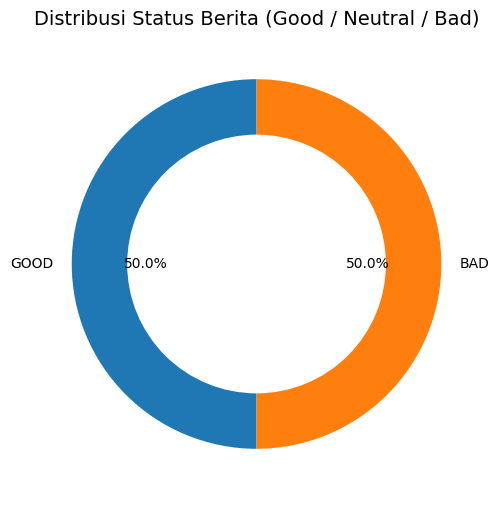

In [110]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kategori status
status_counts = df_new['Status'].value_counts()

# Buat diagram donat
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # Membuat donat (lubang di tengah)
)

# Tambahkan lingkaran putih di tengah
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Judul
plt.title('Distribusi Status Berita (Good / Neutral / Bad)', fontsize=14)

# Tampilkan grafik
plt.show()


In [111]:
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset
import ast
import numpy as np


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class IndoBertDataset(Dataset):
    def __init__(self, df, labels, device=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.device = device

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Ambil vector ---
        vec = row["vec_judul"]

        # Jika string format numpy array -> ubah ke np.array
        if isinstance(vec, str):
            vec = np.fromstring(vec.strip("[]"), sep=" ")

        if isinstance(vec, np.ndarray):
            x = torch.from_numpy(vec).float()
        else:
            x = torch.tensor(vec, dtype=torch.float)

        # --- Normalisasi ke 0..1 ---
        '''
        if x.numel() > 0:  # pastikan tidak kosong
            min_val, max_val = x.min(), x.max()
            if (max_val - min_val) > 0:  # hindari div 0
                x = (x - min_val) / (max_val - min_val)
        '''

        # --- Tambahkan kolom day ---
        #if "day" in row:
        #    day_val = float(row["day"])
        #    day_tensor = torch.tensor([day_val], dtype=torch.float)
        #    x = torch.cat([x, day_tensor], dim=0)

        # --- Ambil target y ---
        y = torch.tensor([float(row[label]) for label in self.labels], dtype=torch.float)

        if self.device:
            x = x.to(self.device)
            y = y.to(self.device)

        return x, y

In [112]:
label = pd.get_dummies(df_new['Status']).astype(int)
df_new = pd.concat([df_new, label], axis=1)
df_new

,day,vec_judul,Status,BAD,GOOD
0,0.2,-0.2656123638153076 0.0783415138721466 0.99104...,GOOD,0,1
1,0.3,-0.5333448052406311 0.025047127157449722 0.997...,GOOD,0,1
2,0.5,-0.5229176878929138 0.20718306303024292 0.9734...,GOOD,0,1
3,0.5,-0.5610884428024292 0.18029376864433289 0.9959...,GOOD,0,1
4,0.1,-0.5184647440910339 0.24151436984539032 0.9941...,GOOD,0,1
...,...,...,...,...,...
13213,0.4,-0.4384211301803589 0.06190809980034828 0.9988...,GOOD,0,1
13214,0.1,-0.5548223257064819 0.0022372473031282425 0.99...,BAD,1,0
13215,0.3,-0.6278557777404785 -0.06579948216676712 0.991...,BAD,1,0
13216,0.1,-0.5916342735290527 0.022360626608133316 0.998...,BAD,1,0


In [113]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_new, test_size=0.2, random_state=42,shuffle=True)


from torch.utils.data import DataLoader
labels =['BAD', 'GOOD']
train_dataset = IndoBertDataset(train_df, labels, device=device)
test_dataset = IndoBertDataset(test_df, labels, device=device)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#train_dataset.__getitem__(1)
len(test_dataset[0][1])
#train_dataset.__len__()
test_dataset[0]

(tensor([-0.6772,  0.0249,  0.9764,  0.9968,  0.0429, -0.9994,  0.1722, -0.0812,
          0.7346, -0.8834,  0.9997,  0.5583, -0.8756, -0.6450, -0.2969, -0.9837,
         -0.9801, -0.3009,  0.1957, -0.5089,  0.7057,  0.9803, -0.9043,  0.9942,
          0.9955, -0.9925, -0.0107, -0.9742,  0.9996, -0.0137,  0.2507,  0.1169,
         -0.3443,  0.3111, -0.9837,  0.9992, -0.1826,  0.4028, -0.3296, -0.2060,
          0.7234,  0.7687,  0.9432,  0.7678,  0.8068, -0.2285, -0.8747,  0.1582,
          0.6950,  0.9097,  0.8453,  0.9802,  0.7856,  0.6254, -0.2425, -0.4314,
          0.9953, -0.4475,  0.9970,  0.9314,  0.1157,  0.3234,  0.3524,  0.5220,
          0.9237,  0.7922, -0.9987,  0.5626, -0.1023, -0.9013, -0.8075,  0.1984,
         -0.3817, -0.5912,  0.9843,  0.1133,  0.7368,  0.7180, -0.3312, -0.5647,
          0.1048, -0.9842,  0.0674, -0.9781,  0.5669,  0.9648, -0.9998,  0.9980,
         -0.8811,  0.9260, -0.0985,  0.4082, -0.9351,  0.8179,  0.3628,  0.8707,
          0.9936,  0.9959,  

In [114]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_dim"      : len(test_dataset[0][0]),
    "hidden_dims"    : [264,64,8],
    "output_dim"     : len(test_dataset[0][1]),
    "dropout"        : 0.1,
    "activation"     : "leakyrelu",
    "early_stop_patience" : 30,
    "col_target"     : ['BAD', 'GOOD'],
    "feature_cols"   : ['vec_judul'],
})
config

Config(activation=leakyrelu, col_target=['BAD', 'GOOD'], dropout=0.1, early_stop_patience=30, feature_cols=['vec_judul'], hidden_dims=[264, 64, 8], input_dim=768, labels=['BAD', 'GOOD'], output_dim=2, threshold=0.5)

In [115]:
from class_lib import MultiLabel1DClassifier
from torch import optim, nn
from jcopdl.callback import Callback
root_folder = "multi-label-clasification"
#Model
model = MultiLabel1DClassifier(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation).to(device)

#Criterion
criterion = nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=1.0)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 38.55it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6943 │ 0.6939 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4997 │ 0.5015 │ │  BAD  │  0.4985  │
│ Subset Accuracy  │ 0.5003 │ 0.4985 │ │ GOOD  │  0.4985  │
│ Micro F1         │ 0.5004 │ 0.4985 │ └───────┴──────────┘
│ Macro F1         │ 0.3335 │ 0.3327 │                     
│ Overall Accuracy │ 0.5003 │ 0.4985 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6943 | Test_cost  = 0.6939 | Train_score = 0.5003 | Test_score = 0.4985 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6931 | Test_cost  = 0.6932 | Train_score = 0.5017 | Test_score = 0.5038 |
==> EarlyStop patience =  7 | Best test_score: 0.5043


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 37.62it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6931 │ 0.6932 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4925 │ 0.5008 │ │  BAD  │  0.4909  │
│ Subset Accuracy  │ 0.2321 │ 0.2803 │ │ GOOD  │  0.5076  │
│ Micro F1         │ 0.4940 │ 0.3784 │ └───────┴──────────┘
│ Macro F1         │ 0.4928 │ 0.3124 │                     
│ Overall Accuracy │ 0.5075 │ 0.4992 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6931 | Test_cost  = 0.6932 | Train_score = 0.5075 | Test_score = 0.4992 |


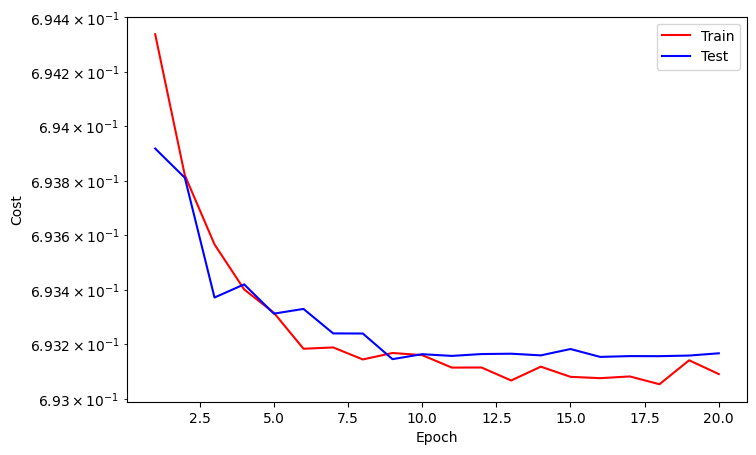

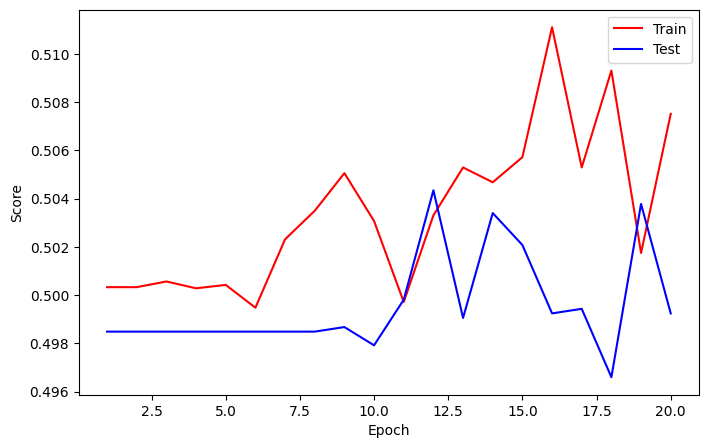

==> EarlyStop patience =  8 | Best test_score: 0.5043


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 36.98it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6930 │ 0.6932 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4886 │ 0.5013 │ │  BAD  │  0.4958  │
│ Subset Accuracy  │ 0.2389 │ 0.2655 │ │ GOOD  │  0.5015  │
│ Micro F1         │ 0.5007 │ 0.3810 │ └───────┴──────────┘
│ Macro F1         │ 0.4969 │ 0.3416 │                     
│ Overall Accuracy │ 0.5114 │ 0.4987 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6930 | Test_cost  = 0.6932 | Train_score = 0.5114 | Test_score = 0.4987 |
==> EarlyStop patience =  9 | Best test_score: 0.5043


...


Epoch    39
Train_cost  = 0.6929 | Test_cost  = 0.6931 | Train_score = 0.5133 | Test_score = 0.5053 |
==> EarlyStop patience =  4 | Best test_score: 0.5078


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 36.40it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6931 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4904 │ 0.4934 │ │  BAD  │  0.5053  │
│ Subset Accuracy  │ 0.3110 │ 0.2436 │ │ GOOD  │  0.5079  │
│ Micro F1         │ 0.4775 │ 0.3376 │ └───────┴──────────┘
│ Macro F1         │ 0.4775 │ 0.3340 │                     
│ Overall Accuracy │ 0.5096 │ 0.5066 │                     
└──────────────────┴────────┴────────┘


Epoch    40
Train_cost  = 0.6931 | Test_cost  = 0.6931 | Train_score = 0.5096 | Test_score = 0.5066 |


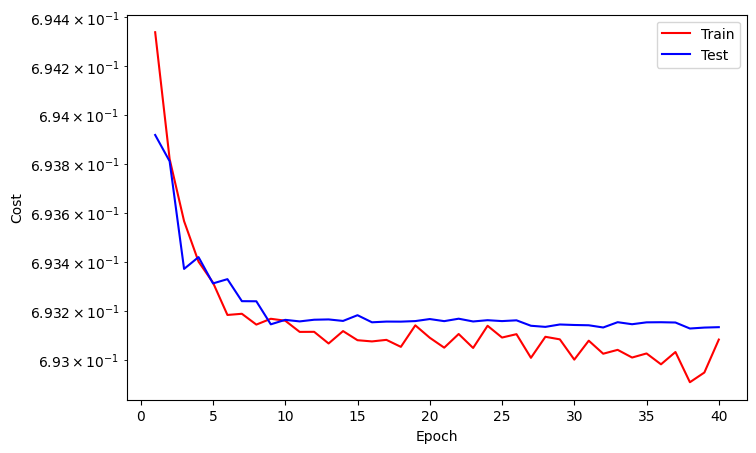

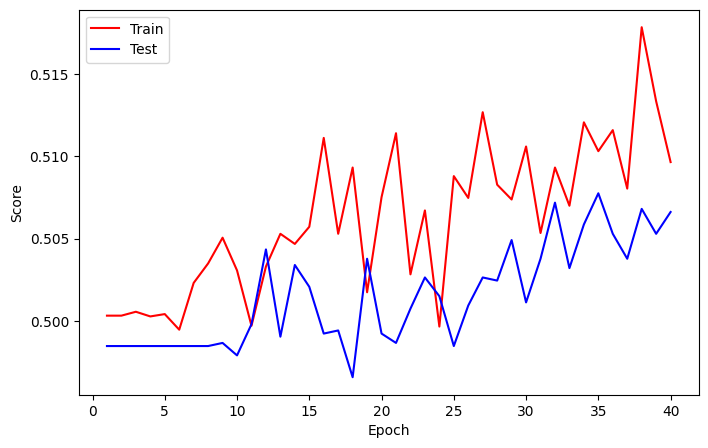

==> EarlyStop patience =  5 | Best test_score: 0.5078


─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 39.09it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6930 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4870 │ 0.4951 │ │  BAD  │  0.5053  │
│ Subset Accuracy  │ 0.3243 │ 0.3154 │ │ GOOD  │  0.5045  │
│ Micro F1         │ 0.4958 │ 0.4058 │ └───────┴──────────┘
│ Macro F1         │ 0.4906 │ 0.3937 │                     
│ Overall Accuracy │ 0.5130 │ 0.5049 │                     
└──────────────────┴────────┴────────┘


Epoch    41
Train_cost  = 0.6930 | Test_cost  = 0.6931 | Train_score = 0.5130 | Test_score = 0.5049 |
==> EarlyStop patience =  6 | Best test_score: 0.5078


...


Epoch    59
Train_cost  = 0.6929 | Test_cost  = 0.6931 | Train_score = 0.5206 | Test_score = 0.5045 |
==> EarlyStop patience =  2 | Best test_score: 0.5087


─────────────────────────────────────────────────── 🚀 EPOCH 60 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 37.87it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6929 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4842 │ 0.4992 │ │  BAD  │  0.5049  │
│ Subset Accuracy  │ 0.3830 │ 0.3865 │ │ GOOD  │  0.4966  │
│ Micro F1         │ 0.5093 │ 0.4458 │ └───────┴──────────┘
│ Macro F1         │ 0.5073 │ 0.4351 │                     
│ Overall Accuracy │ 0.5158 │ 0.5008 │                     
└──────────────────┴────────┴────────┘


Epoch    60
Train_cost  = 0.6929 | Test_cost  = 0.6931 | Train_score = 0.5158 | Test_score = 0.5008 |


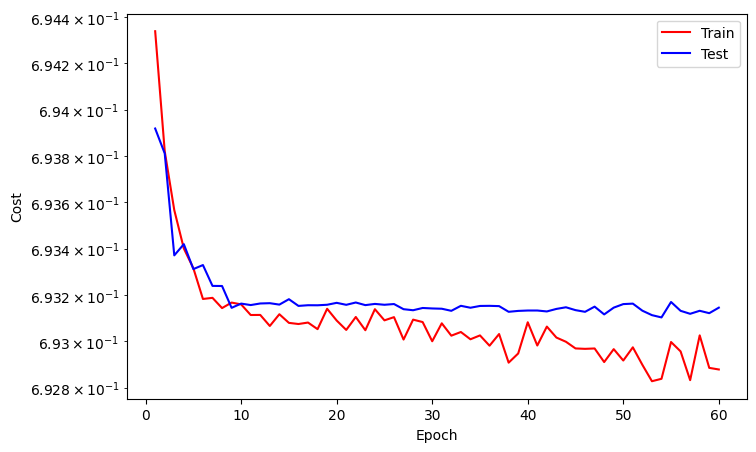

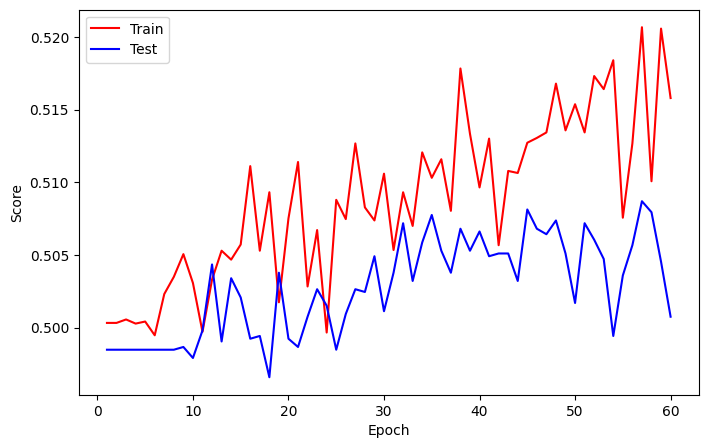

==> EarlyStop patience =  3 | Best test_score: 0.5087


─────────────────────────────────────────────────── 🚀 EPOCH 61 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 37.96it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4861 │ 0.4943 │ │  BAD  │  0.5064  │
│ Subset Accuracy  │ 0.3927 │ 0.4092 │ │ GOOD  │  0.5049  │
│ Micro F1         │ 0.5150 │ 0.4572 │ └───────┴──────────┘
│ Macro F1         │ 0.5091 │ 0.4005 │                     
│ Overall Accuracy │ 0.5139 │ 0.5057 │                     
└──────────────────┴────────┴────────┘


Epoch    61
Train_cost  = 0.6928 | Test_cost  = 0.6931 | Train_score = 0.5139 | Test_score = 0.5057 |
==> EarlyStop patience =  4 | Best test_score: 0.5087


...


Epoch    79
Train_cost  = 0.6927 | Test_cost  = 0.6931 | Train_score = 0.5231 | Test_score = 0.5034 |
==> EarlyStop patience =  2 | Best test_score: 0.5093


─────────────────────────────────────────────────── 🚀 EPOCH 80 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 35.24it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6927 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4825 │ 0.4953 │ │  BAD  │  0.5068  │
│ Subset Accuracy  │ 0.4347 │ 0.4380 │ │ GOOD  │  0.5026  │
│ Micro F1         │ 0.5176 │ 0.4712 │ └───────┴──────────┘
│ Macro F1         │ 0.5160 │ 0.4696 │                     
│ Overall Accuracy │ 0.5175 │ 0.5047 │                     
└──────────────────┴────────┴────────┘


Epoch    80
Train_cost  = 0.6927 | Test_cost  = 0.6931 | Train_score = 0.5175 | Test_score = 0.5047 |


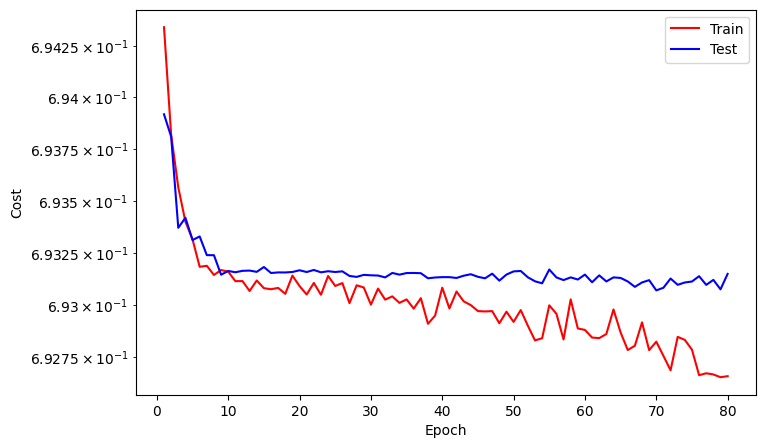

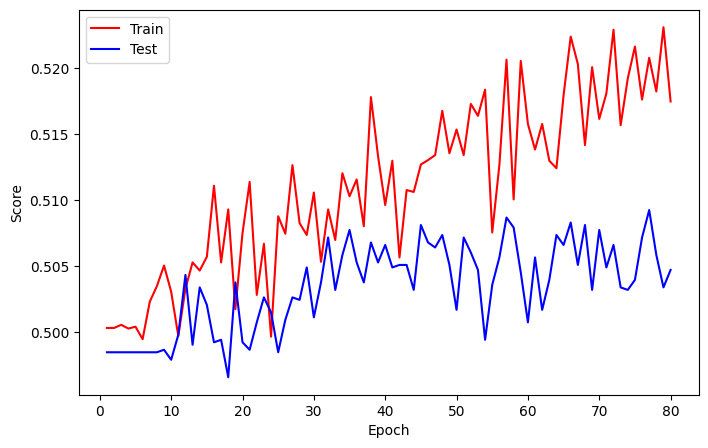

==> EarlyStop patience =  3 | Best test_score: 0.5093


─────────────────────────────────────────────────── 🚀 EPOCH 81 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 29.13it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4861 │ 0.4945 │ │  BAD  │  0.5045  │
│ Subset Accuracy  │ 0.4334 │ 0.4414 │ │ GOOD  │  0.5064  │
│ Micro F1         │ 0.5122 │ 0.4739 │ └───────┴──────────┘
│ Macro F1         │ 0.5113 │ 0.4737 │                     
│ Overall Accuracy │ 0.5139 │ 0.5055 │                     
└──────────────────┴────────┴────────┘


Epoch    81
Train_cost  = 0.6928 | Test_cost  = 0.6931 | Train_score = 0.5139 | Test_score = 0.5055 |
==> EarlyStop patience =  4 | Best test_score: 0.5093


...


Epoch    99
Train_cost  = 0.6928 | Test_cost  = 0.6930 | Train_score = 0.5096 | Test_score = 0.5087 |
==> EarlyStop patience = 22 | Best test_score: 0.5093


────────────────────────────────────────────────── 🚀 EPOCH 100 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 37.12it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6925 │ 0.6931 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4818 │ 0.4970 │ │  BAD  │  0.5076  │
│ Subset Accuracy  │ 0.4643 │ 0.4622 │ │ GOOD  │  0.4985  │
│ Micro F1         │ 0.5175 │ 0.4833 │ └───────┴──────────┘
│ Macro F1         │ 0.5155 │ 0.4770 │                     
│ Overall Accuracy │ 0.5182 │ 0.5030 │                     
└──────────────────┴────────┴────────┘


Epoch   100
Train_cost  = 0.6925 | Test_cost  = 0.6931 | Train_score = 0.5182 | Test_score = 0.5030 |


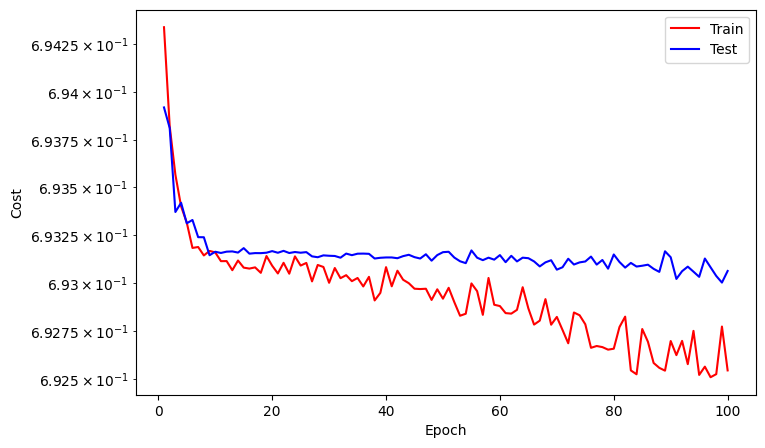

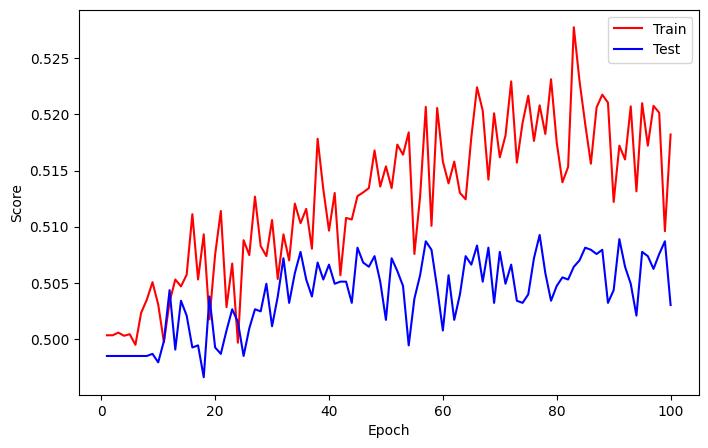

==> EarlyStop patience = 23 | Best test_score: 0.5093


────────────────────────────────────────────────── 🚀 EPOCH 101 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 41.73it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6926 │ 0.6930 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4862 │ 0.4947 │ │  BAD  │  0.5057  │
│ Subset Accuracy  │ 0.4653 │ 0.4762 │ │ GOOD  │  0.5049  │
│ Micro F1         │ 0.5120 │ 0.4932 │ └───────┴──────────┘
│ Macro F1         │ 0.5063 │ 0.4850 │                     
│ Overall Accuracy │ 0.5138 │ 0.5053 │                     
└──────────────────┴────────┴────────┘


Epoch   101
Train_cost  = 0.6926 | Test_cost  = 0.6930 | Train_score = 0.5138 | Test_score = 0.5053 |
==> EarlyStop patience = 24 | Best test_score: 0.5093


...


Epoch   106
Train_cost  = 0.6923 | Test_cost  = 0.6930 | Train_score = 0.5229 | Test_score = 0.5093 |
==> EarlyStop patience = 29 | Best test_score: 0.5093


────────────────────────────────────────────────── 🚀 EPOCH 107 ───────────────────────────────────────────────────

test: 100%|██████████| 42/42 [00:01<00:00, 41.89it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6922 │ 0.6930 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4783 │ 0.4917 │ │  BAD  │  0.5076  │
│ Subset Accuracy  │ 0.4750 │ 0.4724 │ │ GOOD  │  0.5091  │
│ Micro F1         │ 0.5193 │ 0.4910 │ └───────┴──────────┘
│ Macro F1         │ 0.5176 │ 0.4899 │                     
│ Overall Accuracy │ 0.5217 │ 0.5083 │                     
└──────────────────┴────────┴────────┘


Epoch   107
Train_cost  = 0.6922 | Test_cost  = 0.6930 | Train_score = 0.5217 | Test_score = 0.5083 |
==> EarlyStop patience = 30 | Best test_score: 0.5093
==> Execute Early Stopping at epoch: 107 | Best test_score: 0.5093
==> Best model is saved at multi-label-clasification


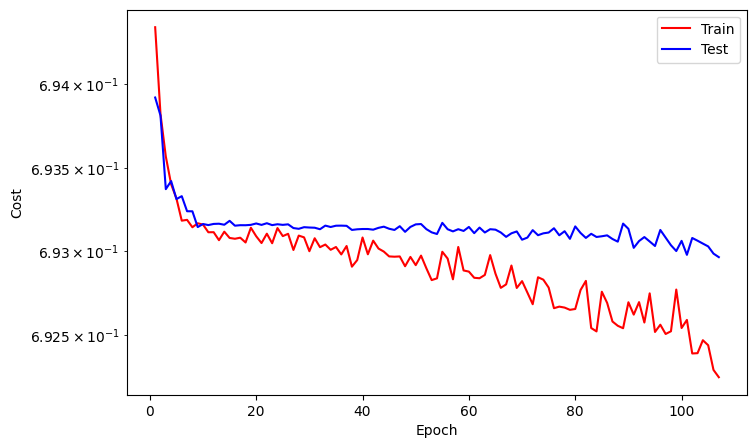

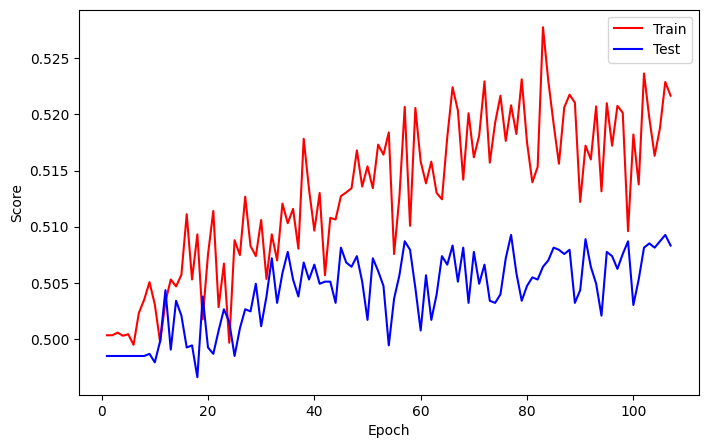

⏹️ Training dihentikan oleh early stopping.

In [116]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

In [119]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, ['BAD', 'GOOD'],criterion, device, config.threshold)

       📊 Evaluasi Model            🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓      Accuracy      
┃ Metrik              ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Akurasi ┃
│ 🔹 Overall Accuracy │ 0.5093 │ ┡━━━━━━━╇━━━━━━━━━┩
│ ✅ Subset  Accuracy │ 0.4523 │ │  BAD  │ 0.5079  │
│ 💥 Loss (avg)       │ 0.6931 │ │ GOOD  │ 0.5106  │
│ 📉 Hamming Loss     │ 0.4907 │ └───────┴─────────┘
│ ⚖️  Micro F1-score   │ 0.4862 │                    
│ 📈 Macro F1-score   │ 0.4762 │                    
└─────────────────────┴────────┘

In [120]:
hsl['df'].head(100)

,Target,Prediksi,Benar (%)
0,"[1.0, 0.0]","[1.0, 0.0]",100.0
1,"[0.0, 1.0]","[0.0, 1.0]",100.0
2,"[0.0, 1.0]","[0.0, 1.0]",100.0
3,"[0.0, 1.0]","[1.0, 0.0]",0.0
4,"[0.0, 1.0]","[0.0, 0.0]",50.0
...,...,...,...
95,"[1.0, 0.0]","[0.0, 1.0]",0.0
96,"[0.0, 1.0]","[0.0, 1.0]",100.0
97,"[0.0, 1.0]","[0.0, 1.0]",100.0
98,"[1.0, 0.0]","[0.0, 1.0]",0.0
